Fitting GARCH...
GARCH fit — alpha=0.0300, lambda=0.9400


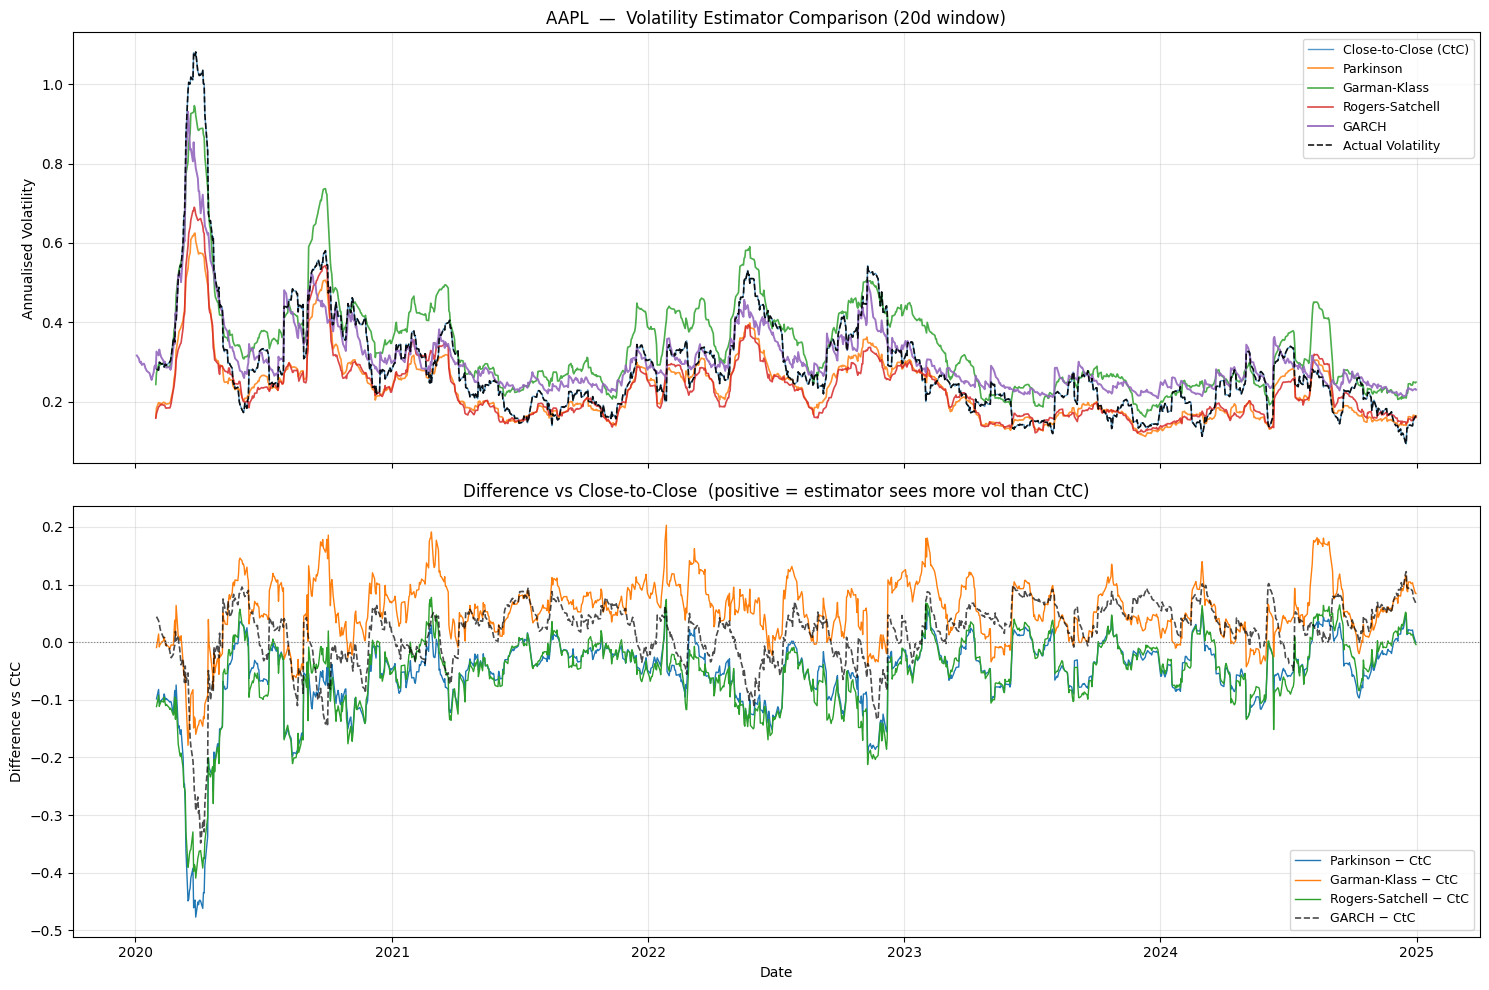

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

NUM_TRADING_DAY = 252

# ─────────────────────────────────────────────────────────────────────────────
# GARCH
# ─────────────────────────────────────────────────────────────────────────────

def GARCH_recursion(returns, alpha, lam):
    sigma_mean2 = returns.var()
    sigma2 = np.zeros(len(returns))
    sigma2[0] = sigma_mean2
    for t in range(1, len(returns)):
        sigma2[t] = alpha * sigma_mean2 + (1 - alpha) * (
            lam * sigma2[t - 1] + (1 - lam) * returns.iloc[t] ** 2
        )
    return sigma2

def objective(parameters, returns):
    alpha, lam = parameters
    if not (0 <= alpha <= 1) or not (0 <= lam <= 1):
        return 1e10
    sigma2 = GARCH_recursion(returns, alpha, lam)
    return np.mean((returns.values ** 2 - sigma2) ** 2)

def fit_GARCH(returns):
    res = minimize(
        objective,
        x0=[0.03, 0.94],
        args=(returns,),
        bounds=[(0.0001, 0.5), (0.5, 0.999)],
    )
    return res.x

def garch_vol(close_series):
    """Fit GARCH on a single Close price Series, return annualised vol Series."""
    returns = np.log(close_series / close_series.shift(1)).dropna()
    alpha, lam = fit_GARCH(returns)
    print(f"GARCH fit — alpha={alpha:.4f}, lambda={lam:.4f}")
    sigma2 = GARCH_recursion(returns, alpha, lam)
    sigma  = np.sqrt(sigma2) * np.sqrt(NUM_TRADING_DAY)
    return pd.Series(sigma, index=returns.index).reindex(close_series.index)

# ─────────────────────────────────────────────────────────────────────────────
# Range-based estimators
# ─────────────────────────────────────────────────────────────────────────────

def close_to_close(ohlc, window=20):
    """Standard HV from log close returns."""
    log_ret = np.log(ohlc["Close"] / ohlc["Close"].shift(1))
    return log_ret.rolling(window).std() * np.sqrt(NUM_TRADING_DAY)

def parkinson(ohlc, window=20):
    """
    Parkinson (1980) — High/Low only.
    Ignores drift and overnight gaps. ~5x more efficient than CtC.
    """
    log_hl = np.log(ohlc["High"] / ohlc["Low"])
    var    = (log_hl ** 2) / (4 * np.log(2))
    return np.sqrt(var.rolling(window).mean() * NUM_TRADING_DAY)

def garman_klass(ohlc, window=20):
    """
    Garman-Klass (1980) — OHLC.
    Yang-Zhang corrected form: handles overnight gaps.
    ~8x more efficient than CtC.
    """
    log_hl  = np.log(ohlc["High"] / ohlc["Low"])
    log_HLO = np.log(ohlc["High"] * ohlc["Low"] / ohlc["Open"] ** 2)
    log_co  = np.log(ohlc["Close"] / ohlc["Open"])
    log_HO  = np.log(ohlc["High"] / ohlc["Open"])
    log_LO  = np.log(ohlc["Low"]  / ohlc["Open"])
    var     = 0.511 * log_hl**2 - 0.019 * log_co * log_HLO - 2 * log_HO * log_LO
    # var can go slightly negative on flat days — clip to 0
    return np.sqrt(var.clip(lower=0).rolling(window).mean() * NUM_TRADING_DAY)

def rogers_satchell(ohlc, window=20):
    """
    Rogers-Satchell (1991) — OHLC, allows non-zero drift.
    Best for trending assets — drift doesn't bias the estimate.
    """
    log_hc = np.log(ohlc["High"] / ohlc["Close"])
    log_ho = np.log(ohlc["High"] / ohlc["Open"])
    log_lc = np.log(ohlc["Low"]  / ohlc["Close"])
    log_lo = np.log(ohlc["Low"]  / ohlc["Open"])
    var    = log_hc * log_ho + log_lc * log_lo
    return np.sqrt(var.clip(lower=0).rolling(window).mean() * NUM_TRADING_DAY)

def historical_volatility(data, window=10):
    data = data["Close"]
    log_returns = np.log(data / data.shift(1))
    return log_returns.rolling(window).std() * np.sqrt(NUM_TRADING_DAY)

# ─────────────────────────────────────────────────────────────────────────────
# Download
# ─────────────────────────────────────────────────────────────────────────────

def download_ohlc(stock, start, end):
    df = yf.Ticker(stock).history(start=start, end=end)
    return df[["Open", "High", "Low", "Close"]].dropna()

# ─────────────────────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────────────────────

def plot_vol_estimators(ohlc, stock, window=20):
    ctc   = close_to_close(ohlc, window)
    pk    = parkinson(ohlc, window)
    gk    = garman_klass(ohlc, window)
    rs    = rogers_satchell(ohlc, window)

    print("Fitting GARCH...")
    garch = garch_vol(ohlc["Close"])
    
    vol = historical_volatility(ohlc, window)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # ── panel 1: all estimators ───────────────────────────────────────────────
    ax = axes[0]
    ax.plot(ctc.index,   ctc.values,            lw=1.0, alpha=0.75, label="Close-to-Close (CtC)")
    ax.plot(pk.index,    pk.values,             lw=1.2, alpha=0.85, label="Parkinson")
    ax.plot(gk.index,    gk.values,             lw=1.2, alpha=0.85, label="Garman-Klass")
    ax.plot(rs.index,    rs.values,             lw=1.2, alpha=0.85, label="Rogers-Satchell")
    ax.plot(garch.index, garch.values,          lw=1.4, alpha=0.90, label="GARCH")
    ax.plot(vol.index,  vol.values,  lw=1.2, alpha=0.9, label="Actual Volatility",
            linestyle="--", color="black")
    ax.set_ylabel("Annualised Volatility")
    ax.set_title(f"{stock}  —  Volatility Estimator Comparison ({window}d window)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── panel 2: difference of each estimator vs CtC ─────────────────────────
    ax = axes[1]
    ax.plot((pk    - ctc).dropna().index, (pk    - ctc).dropna().values, lw=1.0, label="Parkinson − CtC")
    ax.plot((gk    - ctc).dropna().index, (gk    - ctc).dropna().values, lw=1.0, label="Garman-Klass − CtC")
    ax.plot((rs    - ctc).dropna().index, (rs    - ctc).dropna().values, lw=1.0, label="Rogers-Satchell − CtC")
    ax.plot((garch - ctc).dropna().index, (garch - ctc).dropna().values, lw=1.2, label="GARCH − CtC",
            linestyle="--", color="black", alpha=0.7)
    ax.axhline(0, color="grey", lw=0.8, linestyle=":")
    ax.set_ylabel("Difference vs CtC")
    ax.set_xlabel("Date")
    ax.set_title("Difference vs Close-to-Close  (positive = estimator sees more vol than CtC)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    stock  = "AAPL"
    start  = "2020-01-01"
    end    = "2025-01-01"
    window = 15

    ohlc = download_ohlc(stock, start, end)
    plot_vol_estimators(ohlc, stock, window)

### The GARCH model/ recurssion + EWMA:
 $$\sigma^2_n = \alpha \overline{\sigma}^2 + (1- \alpha) (\lambda \sigma^2_{n-1} + (1-\lambda)R^2_n)$$

### Parkinson - 1980 
$$\sigma^2_{parkinson} = \frac{1}{4nlog(2)}\Sigma^n_{i=1}(log(\frac{H_i}{L_i}))^2$$

### Garman & Klass - 1980

$$\sigma^2_{gk} = \frac{1}{n} \Sigma^n_{i=1}(0.551 log(\frac{H_i}{L_i})^2 - 0.019log(\frac{C_i}{O_i})log(\frac{H_iL_i}{O_i^2}) - 2log(\frac{H_i}{O_i})log(\frac{L_i}{O_i})$$

### Rogers & Satchell - 1991
$$\sigma^2_{rs} = \frac{1}{n} \Sigma^n_{i=1}log(\frac{H_i}{C_i})log(\frac{H_i}{O_i}) + log(\frac{L_i}{C_i})log(\frac{L_i}{O_i})$$

from this, interestingly, Rogers & Satchell performs the best for this one!!!"